# Финальный проект

DR и кластеризация на текстовом датасете 20 Newsgroups.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.random_projection import SparseRandomProjection
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score

RANDOM_STATE = 42

## Данные

20 Newsgroups: реальные тексты из тематических групп. TF-IDF дает высокоразмерное разреженное представление документов.

In [6]:
categories = [
    'comp.graphics',
    'rec.sport.hockey',
    'sci.med',
    'sci.space',
    'talk.politics.guns',
    'talk.religion.misc'
]

dataset = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    shuffle=True,
    random_state=RANDOM_STATE
)

texts = np.array(dataset.data)
y = np.array(dataset.target)
target_names = np.array(dataset.target_names)

splitter = StratifiedShuffleSplit(n_splits=1, train_size=1800, random_state=RANDOM_STATE)
idx, _ = next(splitter.split(texts, y))
texts = texts[idx]
y = y[idx]

vectorizer = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.65, stop_words='english')
X_tfidf = vectorizer.fit_transform(texts)
terms = np.array(vectorizer.get_feature_names_out())

print(len(texts))
print(X_tfidf.shape)
print(pd.Series(target_names[y]).value_counts().sort_index())

1800
(1800, 5000)
comp.graphics         319
rec.sport.hockey      328
sci.med               325
sci.space             324
talk.politics.guns    298
talk.religion.misc    206
Name: count, dtype: int64


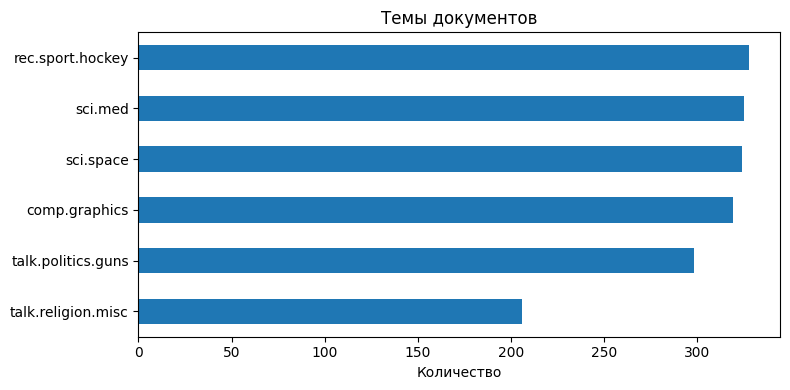

In [7]:
plt.figure(figsize=(8, 4))
pd.Series(target_names[y]).value_counts().sort_values().plot(kind='barh')
plt.title('Темы документов')
plt.xlabel('Количество')
plt.tight_layout()

## Пайплайны

DR: TruncatedSVD, NMF, SparseRandomProjection. Кластеризация: KMeans, AgglomerativeClustering, GaussianMixture.

In [8]:
def dr_models(seed):
    return {
        'TruncatedSVD': TruncatedSVD(n_components=25, random_state=seed),
        'NMF': NMF(n_components=25, init='nndsvda', max_iter=350, random_state=seed),
        'RandomProjection': SparseRandomProjection(n_components=25, random_state=seed)
    }

def dense(Z):
    if hasattr(Z, 'toarray'):
        return Z.toarray()
    return np.asarray(Z)

def cluster_labels(name, Z, seed):
    if name == 'KMeans':
        return KMeans(n_clusters=6, n_init=20, random_state=seed).fit_predict(Z)
    if name == 'Agglomerative':
        return AgglomerativeClustering(n_clusters=6, linkage='ward').fit_predict(Z)
    if name == 'GaussianMixture':
        return GaussianMixture(n_components=6, covariance_type='full', n_init=3, random_state=seed).fit_predict(Z)

cluster_names = ['KMeans', 'Agglomerative', 'GaussianMixture']

In [9]:
embeddings = {}
labels_by_pipeline = {}
rows = []

for dr_name, dr in dr_models(RANDOM_STATE).items():
    Z = dense(dr.fit_transform(X_tfidf))
    embeddings[dr_name] = Z
    for cl_name in cluster_names:
        labels = cluster_labels(cl_name, Z, RANDOM_STATE)
        labels_by_pipeline[(dr_name, cl_name)] = labels
        rows.append({
            'DR': dr_name,
            'cluster': cl_name,
            'silhouette': silhouette_score(Z, labels),
            'davies_bouldin': davies_bouldin_score(Z, labels),
            'ARI': adjusted_rand_score(y, labels),
            'NMI': normalized_mutual_info_score(y, labels),
            'homogeneity': homogeneity_score(y, labels),
            'completeness': completeness_score(y, labels)
        })

results = pd.DataFrame(rows).sort_values(['ARI', 'silhouette'], ascending=[False, False]).reset_index(drop=True)
results

,DR,cluster,silhouette,davies_bouldin,ARI,NMI,homogeneity,completeness
0,TruncatedSVD,GaussianMixture,0.031658,2.760771,0.392084,0.434657,0.417770,0.452966
1,NMF,GaussianMixture,0.014350,3.657890,0.316793,0.346878,0.341369,0.352566
2,TruncatedSVD,Agglomerative,0.115555,2.160088,0.203090,0.403628,0.349438,0.477708
3,TruncatedSVD,KMeans,0.128358,2.205690,0.198532,0.413872,0.370768,0.468317
4,NMF,KMeans,0.254663,1.648444,0.066774,0.285007,0.217391,0.413674
5,NMF,Agglomerative,0.202018,1.551647,0.053023,0.277468,0.205933,0.425151
6,RandomProjection,KMeans,0.045927,3.490604,0.020203,0.029915,0.028541,0.031429
7,RandomProjection,GaussianMixture,-0.063370,11.238001,0.006748,0.012736,0.012148,0.013384
8,RandomProjection,Agglomerative,0.011739,4.380967,0.004211,0.010273,0.009127,0.011746


## Визуализация

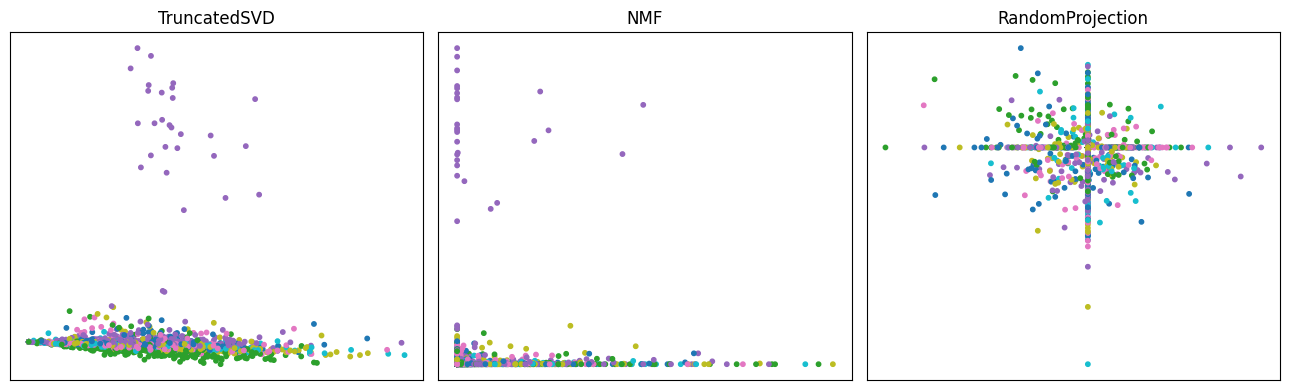

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (dr_name, Z) in zip(axes, embeddings.items()):
    ax.scatter(Z[:, 0], Z[:, 1], c=y, s=10, cmap='tab10')
    ax.set_title(dr_name)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

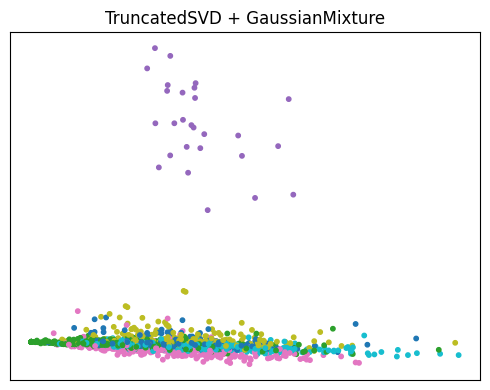

In [11]:
best_dr = results.loc[0, 'DR']
best_cluster = results.loc[0, 'cluster']
best_labels = labels_by_pipeline[(best_dr, best_cluster)]
Z_best = embeddings[best_dr]

plt.figure(figsize=(5, 4))
plt.scatter(Z_best[:, 0], Z_best[:, 1], c=best_labels, s=10, cmap='tab10')
plt.title(best_dr + ' + ' + best_cluster)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

## Устойчивость

In [12]:
def stability_for_pipeline(dr_name, cl_name, n_runs=3, sample_size=0.75):
    rng = np.random.default_rng(RANDOM_STATE)
    runs = []
    for i in range(n_runs):
        idx = np.sort(rng.choice(X_tfidf.shape[0], int(X_tfidf.shape[0] * sample_size), replace=False))
        dr = dr_models(RANDOM_STATE + i)[dr_name]
        Z = dense(dr.fit_transform(X_tfidf[idx]))
        labels = cluster_labels(cl_name, Z, RANDOM_STATE + i)
        runs.append((idx, labels))
    scores = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            idx_i, labels_i = runs[i]
            idx_j, labels_j = runs[j]
            common, pos_i, pos_j = np.intersect1d(idx_i, idx_j, return_indices=True)
            scores.append(adjusted_rand_score(labels_i[pos_i], labels_j[pos_j]))
    return float(np.mean(scores))

stability_rows = []
for dr_name in dr_models(RANDOM_STATE).keys():
    for cl_name in cluster_names:
        stability_rows.append({
            'DR': dr_name,
            'cluster': cl_name,
            'stability_ARI': stability_for_pipeline(dr_name, cl_name)
        })

stability = pd.DataFrame(stability_rows)
summary = results.merge(stability, on=['DR', 'cluster']).sort_values(['ARI', 'stability_ARI'], ascending=[False, False]).reset_index(drop=True)
summary

,DR,cluster,silhouette,davies_bouldin,ARI,NMI,homogeneity,completeness,stability_ARI
0,TruncatedSVD,GaussianMixture,0.031658,2.760771,0.392084,0.434657,0.417770,0.452966,0.397972
1,NMF,GaussianMixture,0.014350,3.657890,0.316793,0.346878,0.341369,0.352566,0.305833
2,TruncatedSVD,Agglomerative,0.115555,2.160088,0.203090,0.403628,0.349438,0.477708,0.314207
3,TruncatedSVD,KMeans,0.128358,2.205690,0.198532,0.413872,0.370768,0.468317,0.722762
4,NMF,KMeans,0.254663,1.648444,0.066774,0.285007,0.217391,0.413674,0.452623
5,NMF,Agglomerative,0.202018,1.551647,0.053023,0.277468,0.205933,0.425151,0.320062
6,RandomProjection,KMeans,0.045927,3.490604,0.020203,0.029915,0.028541,0.031429,0.027452
7,RandomProjection,GaussianMixture,-0.063370,11.238001,0.006748,0.012736,0.012148,0.013384,0.079952
8,RandomProjection,Agglomerative,0.011739,4.380967,0.004211,0.010273,0.009127,0.011746,0.012650


## Интерпретация кластеров

In [13]:
composition = pd.crosstab(best_labels, target_names[y])
composition_norm = composition.div(composition.sum(axis=1), axis=0)
interpretation = pd.DataFrame({
    'cluster': composition.index,
    'main_topic': composition_norm.idxmax(axis=1).values,
    'purity': composition_norm.max(axis=1).round(3).values,
    'size': composition.sum(axis=1).values
})
interpretation.sort_values('cluster')

,cluster,main_topic,purity,size
0,0,comp.graphics,0.755,319
1,1,sci.space,0.527,465
2,2,sci.med,1.000,27
3,3,rec.sport.hockey,0.942,294
4,4,sci.med,0.591,276
5,5,talk.politics.guns,0.513,419


In [14]:
composition_norm.round(2)

col_0,comp.graphics,rec.sport.hockey,sci.med,sci.space,talk.politics.guns,talk.religion.misc
row_0,,,,,,
0,0.76,0.02,0.11,0.09,0.02,0.01
1,0.11,0.05,0.14,0.53,0.07,0.10
2,0.00,0.00,1.00,0.00,0.00,0.00
3,0.00,0.94,0.01,0.02,0.02,0.02
4,0.08,0.07,0.59,0.07,0.15,0.05
5,0.01,0.01,0.08,0.06,0.51,0.33


In [15]:
top_words = []
for cluster in np.sort(np.unique(best_labels)):
    weights = np.asarray(X_tfidf[best_labels == cluster].mean(axis=0)).ravel()
    words = terms[np.argsort(weights)[-12:][::-1]]
    top_words.append({'cluster': cluster, 'words': ', '.join(words)})

pd.DataFrame(top_words)

,cluster,words
0,0,"thanks, graphics, does, know, program, file, i..."
1,1,"space, orbit, nasa, launch, earth, like, just,..."
2,2,"n3jxp, chastity, shameful, dsl, skepticism, in..."
3,3,"game, hockey, games, team, play, don, nhl, esp..."
4,4,"don, edu, com, know, just, like, msg, disease,..."
5,5,"people, gun, god, don, did, think, fbi, right,..."


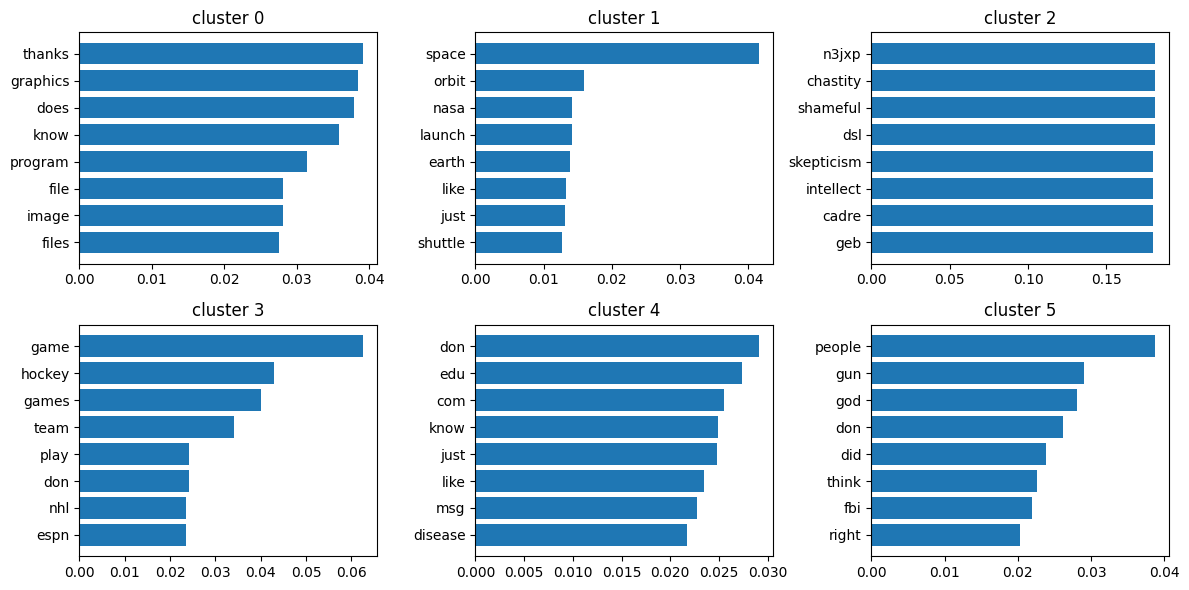

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, cluster in zip(axes.ravel(), np.sort(np.unique(best_labels))):
    weights = np.asarray(X_tfidf[best_labels == cluster].mean(axis=0)).ravel()
    order = np.argsort(weights)[-8:]
    ax.barh(terms[order], weights[order])
    ax.set_title('cluster ' + str(cluster))
plt.tight_layout()

## Итог

In [17]:
best = summary.iloc[0]
stable = summary.sort_values('stability_ARI', ascending=False).iloc[0]

print('Лучшее качество по ARI:', best['DR'], '+', best['cluster'], 'ARI =', round(best['ARI'], 3), 'stability =', round(best['stability_ARI'], 3))
print('Самая высокая устойчивость:', stable['DR'], '+', stable['cluster'], 'stability =', round(stable['stability_ARI'], 3), 'ARI =', round(stable['ARI'], 3))
print('Интерпретация: темы кластеров читаются через наиболее весомые TF-IDF слова и состав исходных newsgroups.')

Лучшее качество по ARI: TruncatedSVD + GaussianMixture ARI = 0.392 stability = 0.398
Самая высокая устойчивость: TruncatedSVD + KMeans stability = 0.723 ARI = 0.199
Интерпретация: темы кластеров читаются через наиболее весомые TF-IDF слова и состав исходных newsgroups.
